<a href="https://colab.research.google.com/github/Halgratir/Gacha-Games/blob/main/Gacha_Games.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import CSV

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

**Load Data**

In [ ]:
df = pd.read_csv('/content/Gacha_Games - Sheet 1.csv')
df.head(10)

,Game_Title,Art_Style,Gacha_Type,Status,Monthly_F2P_Pull_Income,Currency_Cost_Per_Pull_USD,Banner_Duration,Platform,Region,Probability_Highest_Rate,Hard_Pity,Hard_Pity_Count,Soft_Pity,Monthly_Downloads,Lifetime_Downloads,Highest_Revenue_Monthly,Lowest_Revenue_Monthly,Age_Rating,Developers
0,100 Sleeping Princes and the Kingdom of Dreams,Anime 2D,Characters,Active,50,2.50,14,"Android, iOS","Japan, China, Taiwan, Korea",0.0350,Yes,No,No,"15,000","12,000,000","5,000,000","120,000",12,GCREST Inc.
1,2.5 Dimensional Seduction: Angels on Stage,Anime 3D,Characters,Service Ending,50,2.20,14,"Android, iOS, PC",Japan,0.0300,Yes,200,Yes,"250,000","2,000,000","2,000,000","20,000",17,Team CARAVAN
2,Compass,Anime 3D,Characters,Active,50,2.00,14,"Android, iOS",Japan,0.0100,No,No,No,"20,000","15,000,000","3,000,000","800,000",12,NHN PlayArt Co. Ltd.
3,ABYSSDIA,Anime 2D,"Characters, Artifacts",Active,50,2.25,14,"Android, iOS, PC","Japan, Global",0.0300,Yes,No,No,"30,000","5,000,000","40,000","5,000",12,"Ring Games Co,. Ltd"
4,Action Tamarin,Anime 3D,"Characters, Supporters",Active,50,2.25,14,"Android, iOS, PC, Nintendo Switch","Japan, Global",0.0300,Yes,100,No,"25,000","3,000,000","800,000","120,000",17,Gremory Games
5,Aether Gazer,Anime 3D,"Characters, Modifiers",Active,70,2.00,21,"Android, iOS, PC","China, Global",0.0160,Yes,140,Yes,"80,000","5,000,000","2,100,000","274,000",12,Yongshi
6,AFK Arena,Stylized 2D,Heroes,Active,80,2.50,14,"Android, iOS",Global,0.0461,Yes,No,No,"40,000","50,000,000","105,400,000","2,000,000",12,Lilith Games
7,AFK Journey,Stylized 3D,Heroes,Active,65,2.25,21,"Android, iOS, PC",Global,0.0205,Yes,40,Yes,"1,200,000","18,000,000","71,800,000","2,590,000",12,Lilith Games
8,Age of Ishtaria,Anime 2D,Cards,Active,50,2.25,14,"Android, iOS, PC","Japan, North America",0.0200,No,No,No,"5,000","5,000,000","1,000,000","30,000",12,Silicon Studio
9,Alchemy Stars,Anime 2D,Characters,Closed,55,2.30,14,"Android, iOS, PC","Global, China",0.0200,Yes,270,No,"50,000","15,000,000","8,000,000","150,000",12,Tourdog Studio


In [ ]:
print(f"Dataset Dimensions: {df.shape}")
df.info()

Dataset Dimensions: (416, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Game_Title                  416 non-null    object 
 1   Art_Style                   416 non-null    object 
 2   Gacha_Type                  414 non-null    object 
 3   Status                      416 non-null    object 
 4   Monthly_F2P_Pull_Income     416 non-null    int64  
 5   Currency_Cost_Per_Pull_USD  416 non-null    float64
 6   Banner_Duration             416 non-null    int64  
 7   Platform                    416 non-null    object 
 8   Region                      368 non-null    object 
 9   Probability_Highest_Rate    416 non-null    float64
 10  Hard_Pity                   416 non-null    object 
 11  Hard_Pity_Count             416 non-null    object 
 12  Soft_Pity                   416 non-null    object 
 13  Month

Success! It reads

If the preview does not load on my github repo. Here is the link to view it: https://nbviewer.org/

**Transform the data**

In [ ]:
df = pd.read_csv('/content/Gacha_Games - Sheet 1.csv')

#Transform the data
df['Highest_Revenue_Monthly'] = df['Highest_Revenue_Monthly'].str.replace(',', '').fillna(0).astype(float)
df['Monthly_Downloads'] = df['Monthly_Downloads'].str.replace(',', '').fillna(0).astype(float)
df['Lifetime_Downloads'] = df['Lifetime_Downloads'].str.replace(',', '').fillna(0).astype(float)
df['Monthly_F2P_Pull_Income'] = df['Monthly_F2P_Pull_Income'].fillna(0)
print("Data Transformation Complete!")

Data Transformation Complete!


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Game_Title                  416 non-null    object 
 1   Art_Style                   416 non-null    object 
 2   Gacha_Type                  414 non-null    object 
 3   Status                      416 non-null    object 
 4   Monthly_F2P_Pull_Income     416 non-null    int64  
 5   Currency_Cost_Per_Pull_USD  416 non-null    float64
 6   Banner_Duration             416 non-null    int64  
 7   Platform                    416 non-null    object 
 8   Region                      368 non-null    object 
 9   Probability_Highest_Rate    416 non-null    float64
 10  Hard_Pity                   416 non-null    object 
 11  Hard_Pity_Count             416 non-null    object 
 12  Soft_Pity                   416 non-null    object 
 13  Monthly_Downloads           416 non

Clean the Art Style column

In [ ]:
df['Art_Style'] = df['Art_Style'].str.strip()

print("Setup and Cleaning Complete!")

Setup and Cleaning Complete!


In [ ]:
#Python FUnction
def categorize_generosity(income):
    #Categorizes games by how many free pulls they give monthly.
    if income >= 80: return "High Generosity"
    if income >= 50: return "Standard"
    return "Stingy"

df['generosity_tier'] = df['Monthly_F2P_Pull_Income'].apply(categorize_generosity)
print("Generosity Tier Added!")

Generosity Tier Added!


CLASS

In [ ]:
class GachaAnalyst:
    def __init__(self, data):
        self.data = data

    def get_summary(self):
        avg_rev = self.data['Highest_Revenue_Monthly'].mean()
        total_games = len(self.data)
        return f"Analyzing {total_games} games with an average peak revenue of ${avg_rev:,.2f}"
# Using the class
analyst = GachaAnalyst(df)
print(analyst.get_summary())

Analyzing 416 games with an average peak revenue of $10,669,962.14


Visualizing Art Style and Revenue

/tmp/ipykernel_2642/2292098949.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=art_comparison.index, y=art_comparison.values, palette='viridis')


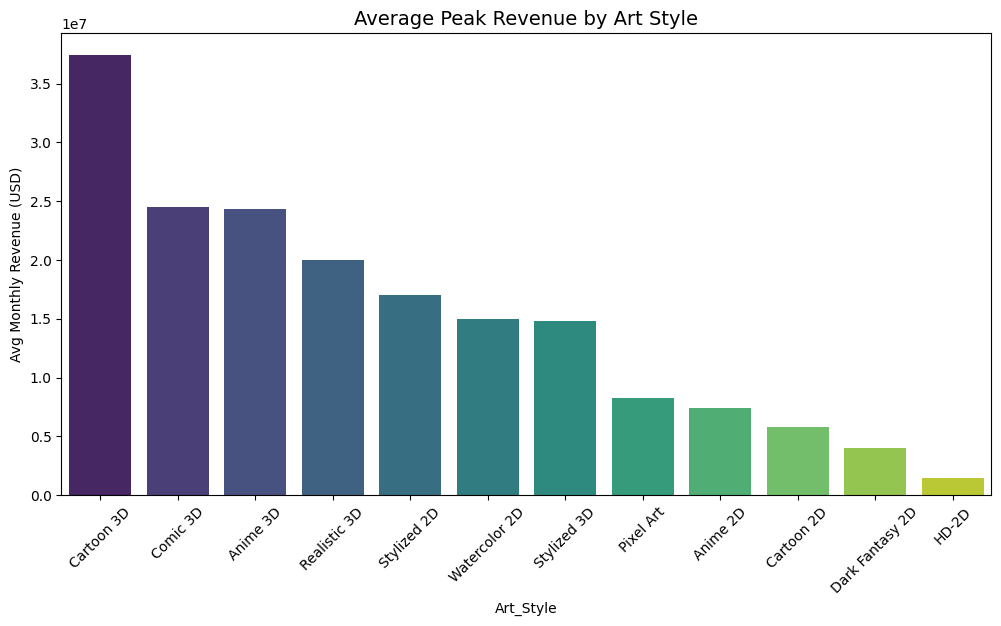

Insight: This chart shows which visual styles the market values most.


In [ ]:
# Statistical Analysis: Grouping by Art Style
art_comparison = df.groupby('Art_Style')['Highest_Revenue_Monthly'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=art_comparison.index, y=art_comparison.values, palette='viridis')
plt.title('Average Peak Revenue by Art Style', fontsize=14)
plt.ylabel('Avg Monthly Revenue (USD)')
plt.xticks(rotation=45)
plt.show()

print("Insight: This chart shows which visual styles the market values most.")

Average popularity by downloads

/tmp/ipykernel_2642/4239451848.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_downloads.values, y=avg_downloads.index, palette='rocket')


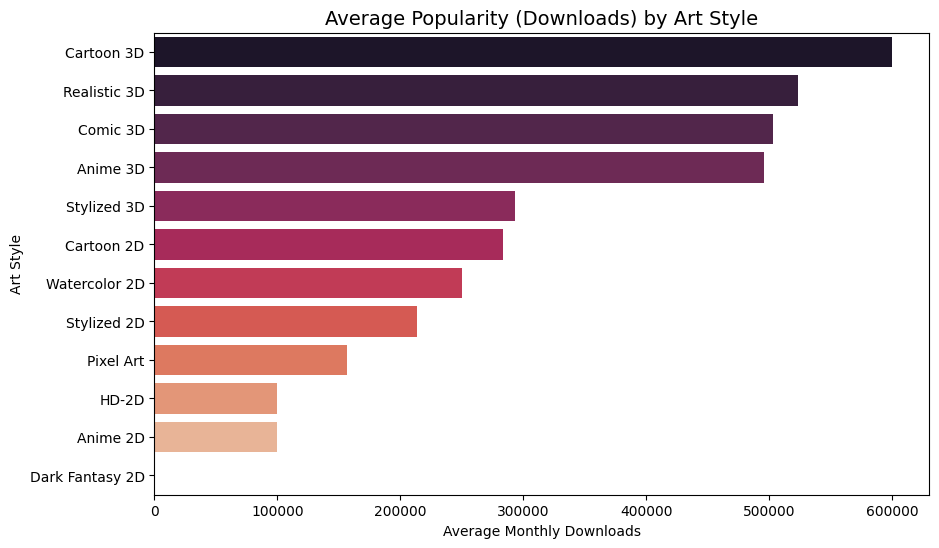

In [ ]:
#Calculating the average downloads per style
avg_downloads = df.groupby('Art_Style')['Monthly_Downloads'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_downloads.values, y=avg_downloads.index, palette='rocket')

plt.title('Average Popularity (Downloads) by Art Style', fontsize=14)
plt.xlabel('Average Monthly Downloads')
plt.ylabel('Art Style')
plt.show()

**Frequency of Art Style**

/tmp/ipykernel_2642/2038019919.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Art_Style', order=df['Art_Style'].value_counts().index, palette='viridis')


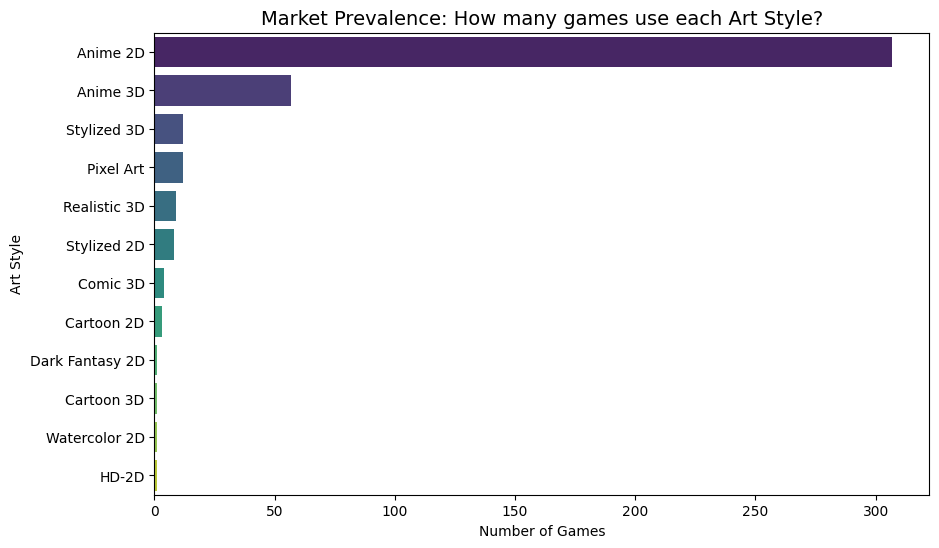

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, y='Art_Style', order=df['Art_Style'].value_counts().index, palette='viridis')

plt.title('Market Prevalence: How many games use each Art Style?', fontsize=14)
plt.xlabel('Number of Games')
plt.ylabel('Art Style')
plt.show()

**Linear Regression**

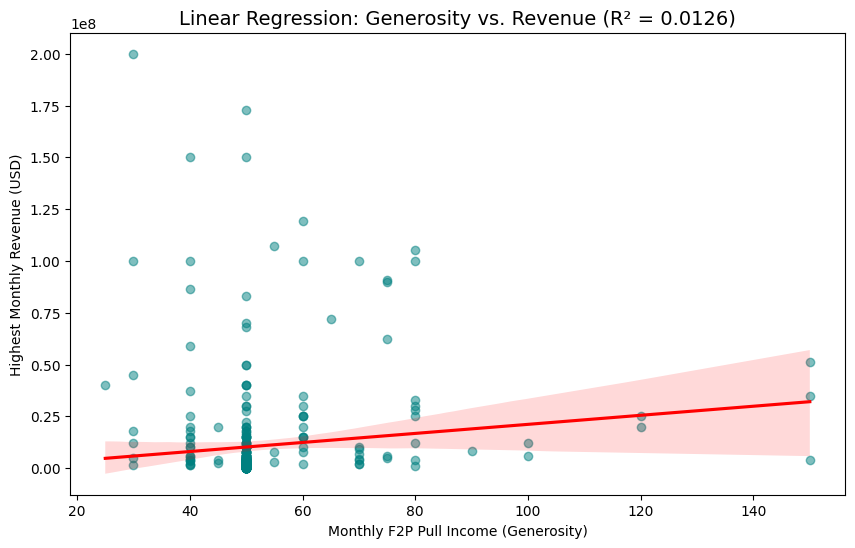

The R-squared value is 0.0126.


In [ ]:
# Prepare data for Linear Regression
X = df[['Monthly_F2P_Pull_Income']]
y = df['Highest_Revenue_Monthly']
model = LinearRegression().fit(X, y)
r_squared = model.score(X, y)

#Visualization
plt.figure(figsize=(10, 6))
sns.regplot(x='Monthly_F2P_Pull_Income', y='Highest_Revenue_Monthly', data=df,
            scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'red'})
plt.title(f'Linear Regression: Generosity vs. Revenue (R² = {r_squared:.4f})', fontsize=14)
plt.xlabel('Monthly F2P Pull Income (Generosity)')
plt.ylabel('Highest Monthly Revenue (USD)')
plt.show()

print(f"The R-squared value is {r_squared:.4f}.")